In [1]:
#! pip install evosax scipy matplotlib seaborn pandas

In [2]:
# Imports
import jax
import jax.numpy as jnp
import malthusjax as mjx
from malthusjax.core.fitness.bbob_evaluator import BBOBEvaluator, BBOBConfig
from evosax.algorithms.population_based.simple_ga import SimpleGA
from evosax.problems import BBOBProblem
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from typing import Dict, List, Tuple
import warnings
from functools import partial
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

DEVICE = jax.devices()

JAX version: 0.8.0
JAX devices: [CpuDevice(id=0)]


## Configuration Parameters

All benchmark parameters in one place for easy modification.
### Available BBOB Benchmark Problems (What you can solve with this notebook)

This notebook supports the standard BBOB function suite. Below are all available problem keys you can set as `PROBLEM_NAME`, grouped by landscape type, with a short description, practical notes for experimentation and the optimization direction used by BBOB (minimization unless noted).

---

#### Part 1 — Separable functions (easy, independent dims)
- `sphere` — Sphere Function  
    Simple quadratic bowl. Global optimum at origin. Good sanity check; converges quickly.  
    Optimization: Minimization
- `ellipsoidal` — Ellipsoidal Function  
    Scaled quadratic with conditioning; still unimodal but ill-conditioned.  
    Optimization: Minimization
- `rastrigin` — Rastrigin Function  
    Many regularly spaced local optima; multimodal but separable structure.  
    Optimization: Minimization
- `bueche_rastrigin` — Büche‑Rastrigin Function  
    Rastrigin variant with additional irregularities; more challenging local traps.  
    Optimization: Minimization
- `linear_slope` — Linear Slope  
    Simple ridge/linear descent; useful to test directional bias.  
    Optimization: Minimization

---

#### Part 2 — Low or moderate conditioning (mild interactions)
- `attractive_sector` — Attractive Sector Function  
    Mostly unimodal but with sector-based features; tests search orientation.  
    Optimization: Minimization
- `step_ellipsoidal` — Step Ellipsoidal Function  
    Discretized/stepped ellipsoidal — plateaus + conditioning.  
    Optimization: Minimization
- `rosenbrock` — Rosenbrock Function  
    Narrow curved valley to optimum — tests local search precision.  
    Optimization: Minimization
- `rosenbrock_rotated` — Rosenbrock (rotated)  
    Same difficulty with variable coupling from rotation.  
    Optimization: Minimization

---

#### Part 3 — High conditioning, unimodal (difficult curvature)
- `ellipsoidal_rotated` — Rotated Ellipsoidal  
    Highly ill-conditioned and with variable coupling — difficult for isotropic mutations.  
    Optimization: Minimization
- `discus` — Discus Function  
    Very large conditioning in one axis — tests anisotropic adaptation.  
    Optimization: Minimization
- `bent_cigar` — Bent Cigar Function  
    Extreme conditioning between axes — one “easy” and many “hard” dims.  
    Optimization: Minimization
- `sharp_ridge` — Sharp Ridge Function  
    Ridge-like structure with sharp transitions — requires precise steps.  
    Optimization: Minimization
- `different_powers` — Different Powers Function  
    Variables scaled by different exponents — tests scale robustness.  
    Optimization: Minimization

---

#### Part 4 — Multi-modal with adequate global structure (global trend present)
- `rastrigin_rotated` — Rastrigin (rotated)  
    Multimodal with variable coupling; global trend still helpful.  
    Optimization: Minimization
- `weierstrass` — Weierstrass Function  
    Fractal-like multi-scale landscape — many local features.  
    Optimization: Minimization
- `schaffers_f7` — Schaffers F7 Function  
    Many local optima but global funnel structure — tests global search power.  
    Optimization: Minimization
- `schaffers_f7_ill_cond` — Schaffers F7 (ill-conditioned)  
    Same as above with added conditioning — harder.  
    Optimization: Minimization
- `griewank_rosenbrock` — Composite Griewank–Rosenbrock (F8F2)  
    Composite landscape mixing rugged and valley features.  
    Optimization: Minimization

---

#### Part 5 — Multi-modal with weak global structure (deceptive)
- `schwefel` — Schwefel Function  
    Many deep distant optima; global optimum far from origin — requires exploration.  
    Optimization: Minimization
- `gallagher_101_me` — Gallagher’s Gaussian 101-me Peaks  
    Many peaks with varying heights; highly multimodal and deceptive.  
    Optimization: Minimization
- `gallagher_21_hi` — Gallagher’s Gaussian 21-hi Peaks  
    Fewer peaks but very rugged and high variability.  
    Optimization: Minimization
- `katsuura` — Katsuura Function  
    Highly irregular with fractal structure; tough for gradient-free optimizers.  
    Optimization: Minimization
- `lunacek` — Lunacek bi‑Rastrigin Function  
    Bimodal with deceptive basin away from global optimum — tests escape mechanisms.  
    Optimization: Minimization

---

### Quick guidance for using/choosing functions
- To run a problem, set PROBLEM_NAME to one of the keys above (e.g., `PROBLEM_NAME = "rastrigin"`). All BBOB problems in this notebook are treated as minimization tasks (the BBOB suite defines targets as minima).
- Use separable/unimodal problems for baseline checks and tuning (mutation strength, population size).
- Use multimodal/weak‑structure problems to evaluate exploration capability (increase population, mutation diversity, restarts).
- For ill-conditioned/unimodal problems prefer adaptive or anisotropic mutation operators (or increase generations and smaller mutation sigma).
- For deceptive landscapes try larger populations, stronger diversity maintenance (elitism trade-offs), or hybrid local search.

---

### Practical tips for experiments in this notebook
- Start with small DIMENSIONS (e.g., 2–10) to debug algorithm settings, then scale to DIMENSIONS = 20+.
- Use NUM_RUNS ≥ 10 for meaningful statistics; warmups are already handled by the runners.
- Compare frameworks by `best_cost`, `runtime`, and `throughput`. Adjust mutation/crossover parameters to match assumptions of each algorithm.
- Add new BBOB functions or custom evaluators by updating the evaluator creation in the runners (follow the existing BBOBConfig/BBOBEvaluator pattern).

---

This list covers the functions available in the notebook. Pick problems based on the landscape features you want to stress-test (conditioning, multi-modality, deception, separability).

In [3]:
# ============================================================================
# BENCHMARK CONFIGURATION - MODIFY THESE PARAMETERS
# ============================================================================

# Problem Configuration
PROBLEM_NAME = "lunacek"  # BBOB function name
DIMENSIONS = 20                     # Problem dimensionality
BOUNDS = (-5.0, 5.0)                # Search space bounds
FIXED_PROBLEM_SEED = 0              # Fixed landscape seed (same problem for all runs)

# Evolution Parameters
POPULATION_SIZE = 100              # Population size
NUM_GENERATIONS = 50               # Number of generations
CROSSOVER_RATE = 0.5                # Crossover probability
ELITE_RATIO = 0.5                   # Proportion of elites to select
MUTATION_RATE = 1.0                 # Mutation probability
MUTATION_STRENGTH = 1.0             # Gaussian mutation strength

# Statistical Parameters
NUM_RUNS = 30                       # Number of independent runs for statistics
BASE_SEED = 42                     # Base random seed (incremented for each run)

# Scenario Configuration
RUN_NOT_COMPILED = True             # Run scenario: not compiled
RUN_COMPILED_NOT_WARMED = True      # Run scenario: compiled but not warmed (includes compile time)
RUN_COMPILED_WARMED = True          # Run scenario: compiled and warmed (steady state)

# Display
VERBOSE = True                      # Print progress during runs
SAVE_IR = True                      # Save lowered IR to files

# Derived parameters
ELITE_POOL_SIZE = int(POPULATION_SIZE * ELITE_RATIO)

print("📋 Benchmark Configuration")
print("=" * 70)
print(f"Problem:          {PROBLEM_NAME} ({DIMENSIONS}D)")
print(f"Population Size:  {POPULATION_SIZE:,}")
print(f"Generations:      {NUM_GENERATIONS}")
print(f"Independent Runs: {NUM_RUNS}")
print(f"Base Seed:        {BASE_SEED}")
print(f"\nScenarios to run:")
print(f"  Not Compiled:           {RUN_NOT_COMPILED}")
print(f"  Compiled (Not Warmed):  {RUN_COMPILED_NOT_WARMED}")
print(f"  Compiled (Warmed):      {RUN_COMPILED_WARMED}")
print("=" * 70)

📋 Benchmark Configuration
Problem:          lunacek (20D)
Population Size:  100
Generations:      50
Independent Runs: 30
Base Seed:        42

Scenarios to run:
  Not Compiled:           True
  Compiled (Not Warmed):  True
  Compiled (Warmed):      True


## Helper Functions

Setup builders and conditional JIT wrapper.

In [4]:
# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def maybe_jit(fn, do_jit: bool):
    """Conditionally apply JIT compilation."""
    return jax.jit(fn) if do_jit else fn


def setup_bbob_problem():
    """Setup BBOB problem and evaluator with fixed seed."""
    # MalthusJAX evaluator
    bbob_config = BBOBConfig(
        fn_name=PROBLEM_NAME,
        num_dims=DIMENSIONS,
        seed=FIXED_PROBLEM_SEED,
        maximize=True  # Flips sign for minimization
    )
    mjx_evaluator = BBOBEvaluator.create(bbob_config)
    
    # Evosax problem
    evosax_problem = BBOBProblem(PROBLEM_NAME, num_dims=DIMENSIONS, seed=FIXED_PROBLEM_SEED)
    
    return mjx_evaluator, evosax_problem


def build_malthusjax_engine(evaluator):
    """Build MalthusJAX engine with configured operators."""
    genome_config = mjx.RealGenomeConfig(length=DIMENSIONS, bounds=BOUNDS)

    
    params = mjx.AbstractEngineParams(
        pop_size=POPULATION_SIZE,
        num_generations=NUM_GENERATIONS,
        elitism=0
    )
    
    selection = mjx.selection.ElitePool(
        num_selections=POPULATION_SIZE,
        elite_k= int(POPULATION_SIZE * ELITE_RATIO)
    )
    
    crossover = mjx.crossover.realUniform(
        num_offspring=2,
        crossover_rate=CROSSOVER_RATE
    )
    
    mutation = mjx.mutation.Gaussian(
        num_offspring=1,
        mutation_rate=MUTATION_RATE,
        mutation_strength=MUTATION_STRENGTH,
        clip=False
    )
    
    engine = mjx.GeneticEngine(
        genome_config=genome_config,
        evaluator=evaluator,
        selection=selection,
        crossover=crossover,
        mutation=mutation,
        engine_params=params
    )
    
    return engine


def build_evosax_strategy(problem):
    """Build Evosax strategy with configured parameters."""
    rng = jax.random.PRNGKey(0)
    init_solution = problem.sample(rng)
    
    strategy = SimpleGA(
        population_size=POPULATION_SIZE,
        solution=init_solution,
        
    )
    strategy.elite_ratio = ELITE_RATIO
    es_params = strategy.default_params.replace(crossover_rate=CROSSOVER_RATE)
    
    print(f'es_params\n{es_params}\n\n\n\n')
    
    return strategy, es_params


print("✅ Helper functions loaded")

✅ Helper functions loaded


## Single Experiment Runners

Functions to run a single experiment for each framework with compilation and warmup toggles.

In [5]:
# ============================================================================
# MALTHUSJAX SINGLE EXPERIMENT RUNNER
# ============================================================================

import functools


def run_malthusjax_single(
    seed: int,
    compile: bool,
    warmup: bool,
    verbose: bool = False
) -> Dict[str, float]:
    """Run a single MalthusJAX experiment with compilation/warmup control."""
    
    # Setup
    mjx_evaluator, _ = setup_bbob_problem()
    engine = build_malthusjax_engine(mjx_evaluator)
    
    
    run_fn = functools.partial(
        engine.run,
        time_it=True,
        compile=compile,
        verbose=verbose
    )
    
    # Initialize state
    key = jax.random.PRNGKey(seed)
    dummy_state = engine.init_state(key)  # Dummy state for compilation
    state = engine.init_state(key)
    
    # Warmup if requested
    if warmup:
        dummy_state, _, _ = run_fn(dummy_state)
        jax.block_until_ready(dummy_state.best_fitness)
        # Re-initialize for measured run
        state = engine.init_state(key)
    
    # Measured run
    # start_time = time.time()
    final_state, history, runtime = run_fn(state)
    jax.block_until_ready(final_state.best_fitness)
    #runtime = time.time() - start_time
    
    # Extract metrics (flip sign back for reporting)
    best_cost = -float(final_state.best_fitness)
    throughput = (POPULATION_SIZE * NUM_GENERATIONS) / runtime
    
    if verbose:
        print(f"  Seed {seed}: Cost={best_cost:.6f}, Time={runtime:.4f}s, "
              f"Throughput={throughput/1e6:.2f}M evals/s")
    
    return {
        'seed': seed,
        'best_cost': best_cost,
        'runtime': runtime,
        'throughput': throughput,
        'framework': 'MalthusJAX',
        'compile': compile,
        'warmup': warmup
    }


print("✅ MalthusJAX runner loaded")

✅ MalthusJAX runner loaded


In [6]:
# ============================================================================
# EVOSAX SINGLE EXPERIMENT RUNNER
# ============================================================================

def run_evosax_single(
    seed: int,
    compile: bool,
    warmup: bool,
    verbose: bool = False
) -> Dict[str, float]:
    """Run a single Evosax experiment with compilation/warmup control."""
    
    # Setup
    _, problem = setup_bbob_problem()
    strategy, es_params = build_evosax_strategy(problem)
    
    # Define step function
    def step_impl(state, param_state, rng):
        rng_ask, rng_eval, rng_tell = jax.random.split(rng, 3)
        x, state = strategy.ask(rng_ask, state, es_params)
        fitness, new_param_state, _ = problem.eval(rng_eval, x, param_state)
        state, metrics = strategy.tell(rng_tell, x, fitness, state, es_params)
        return state, new_param_state, fitness
    
    step = maybe_jit(step_impl, compile)
    
    # Define evolution loop
    def scan_step(carry, _):
        state, prob_state, rng = carry
        rng, rng_step = jax.random.split(rng)
        new_state, new_prob_state, _ = step(state, prob_state, rng_step)
        return (new_state, new_prob_state, rng), None
    
    def run_evolution_impl(state, prob_state, rng):
        return jax.lax.scan(
            scan_step,
            (state, prob_state, rng),
            None,
            length=NUM_GENERATIONS
        )
    
    run_evolution = maybe_jit(run_evolution_impl, compile)
    
    # Initialize
    rng = jax.random.PRNGKey(seed)
    rng, rng_init, rng_pop = jax.random.split(rng, 3)
    
    initial_pop = jax.random.uniform(
        rng_pop,
        (POPULATION_SIZE, DIMENSIONS),
        minval=BOUNDS[0],
        maxval=BOUNDS[1]
    )
    initial_fitness = jnp.full((POPULATION_SIZE,), jnp.inf)
    state = strategy.init(rng_init, initial_pop, initial_fitness, es_params)
    prob_state = problem.init(jax.random.PRNGKey(FIXED_PROBLEM_SEED))
    
    # Warmup if requested
    if warmup:
        (_state, _prob_state, _rng), _ = run_evolution(state, prob_state, rng)
        jax.block_until_ready(_state.best_fitness)
    
    # Measured run
    start_time = time.time()
    (state, prob_state, rng), _ = run_evolution(state, prob_state, rng)
    jax.block_until_ready(state.best_fitness)
    runtime = time.time() - start_time
    
    # Extract metrics
    best_cost = float(state.best_fitness)
    throughput = (POPULATION_SIZE * NUM_GENERATIONS) / runtime
    
    if verbose:
        print(f"  Seed {seed}: Cost={best_cost:.6f}, Time={runtime:.4f}s, "
              f"Throughput={throughput/1e6:.2f}M evals/s")
    
    return {
        'seed': seed,
        'best_cost': best_cost,
        'runtime': runtime,
        'throughput': throughput,
        'framework': 'Evosax',
        'compile': compile,
        'warmup': warmup
    }


print("✅ Evosax runner loaded")

✅ Evosax runner loaded


## Benchmark Orchestrator

Run experiments across all scenarios and frameworks.

In [7]:
# ============================================================================
# BENCHMARK ORCHESTRATOR
# ============================================================================

def run_benchmark_for_scenarios(
    num_runs: int,
    verbose: bool = True
) -> pd.DataFrame:
    """Run benchmark across all enabled scenarios."""
    
    scenarios = []
    
    if RUN_NOT_COMPILED:
        scenarios.append({
            'name': 'not_compiled',
            'label': 'Not Compiled',
            'compile': False,
            'warmup': False
        })
    
    if RUN_COMPILED_NOT_WARMED:
        scenarios.append({
            'name': 'compiled_not_warmed',
            'label': 'Compiled (Not Warmed)',
            'compile': True,
            'warmup': False
        })
    
    if RUN_COMPILED_WARMED:
        scenarios.append({
            'name': 'compiled_warmed',
            'label': 'Compiled (Warmed)',
            'compile': True,
            'warmup': True
        })
    
    all_results = []
    
    print("\n🚀 Running Benchmark Across All Scenarios")
    print("=" * 70)
    
    for scenario in scenarios:
        if verbose:
            print(f"\n📊 Scenario: {scenario['label']}")
            print(f"   Compile={scenario['compile']}, Warmup={scenario['warmup']}")
            print("-" * 70)
        
        # Run MalthusJAX
        if verbose:
            print("\n  🔧 MalthusJAX:")
        
        for i in range(num_runs):
            seed = BASE_SEED + i
            result = run_malthusjax_single(
                seed=seed,
                compile=scenario['compile'],
                warmup=scenario['warmup'],
                verbose=verbose
            )
            result['scenario'] = scenario['name']
            result['scenario_label'] = scenario['label']
            all_results.append(result)
        
        # Run Evosax
        if verbose:
            print("\n  🥊 Evosax:")
        
        for i in range(num_runs):
            seed = BASE_SEED + i
            result = run_evosax_single(
                seed=seed,
                compile=scenario['compile'],
                warmup=scenario['warmup'],
                verbose=verbose
            )
            result['scenario'] = scenario['name']
            result['scenario_label'] = scenario['label']
            all_results.append(result)
    
    df = pd.DataFrame(all_results)
    
    if verbose:
        print("\n" + "=" * 70)
        print("✅ Benchmark complete!")
        print("=" * 70)
    
    return df


print("✅ Orchestrator loaded")

✅ Orchestrator loaded


## Statistical Analysis Functions

In [8]:
# ============================================================================
# STATISTICAL ANALYSIS
# ============================================================================

def compute_statistics(df: pd.DataFrame, metric: str) -> Dict[str, float]:
    """Compute statistical summary for a metric."""
    values = df[metric].values
    
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)
    median_val = np.median(values)
    min_val = np.min(values)
    max_val = np.max(values)
    
    n = len(values)
    if n > 1:
        sem = std_val / np.sqrt(n)
        ci = stats.t.interval(0.95, n-1, loc=mean_val, scale=sem)
    else:
        ci = (mean_val, mean_val)
    
    return {
        'mean': mean_val,
        'std': std_val,
        'median': median_val,
        'min': min_val,
        'max': max_val,
        'ci_lower': ci[0],
        'ci_upper': ci[1],
        'n': n
    }


def compare_frameworks_by_scenario(df_all: pd.DataFrame) -> pd.DataFrame:
    """Statistical comparison between frameworks grouped by scenario."""
    
    results = []
    
    for scenario in df_all['scenario_label'].unique():
        df_scenario = df_all[df_all['scenario_label'] == scenario]
        
        for framework in ['MalthusJAX', 'Evosax']:
            df_fw = df_scenario[df_scenario['framework'] == framework]
            
            cost_stats = compute_statistics(df_fw, 'best_cost')
            time_stats = compute_statistics(df_fw, 'runtime')
            throughput_stats = compute_statistics(df_fw, 'throughput')
            
            results.append({
                'Scenario': scenario,
                'Framework': framework,
                'Cost (mean±std)': f"{cost_stats['mean']:.6f} ± {cost_stats['std']:.6f}",
                'Runtime (mean±std)': f"{time_stats['mean']:.4f} ± {time_stats['std']:.4f}",
                'Throughput (M/s)': f"{throughput_stats['mean']/1e6:.2f} ± {throughput_stats['std']/1e6:.2f}",
            })
    
    comparison_df = pd.DataFrame(results)
    
    # Statistical tests per scenario
    print("\n" + "="*80)
    print("STATISTICAL TESTS BY SCENARIO")
    print("="*80)
    
    for scenario in df_all['scenario_label'].unique():
        df_scenario = df_all[df_all['scenario_label'] == scenario]
        
        mjx_cost = df_scenario[df_scenario['framework'] == 'MalthusJAX']['best_cost'].values
        evosax_cost = df_scenario[df_scenario['framework'] == 'Evosax']['best_cost'].values
        mjx_time = df_scenario[df_scenario['framework'] == 'MalthusJAX']['runtime'].values
        evosax_time = df_scenario[df_scenario['framework'] == 'Evosax']['runtime'].values
        
        cost_ttest = stats.ttest_ind(mjx_cost, evosax_cost, equal_var=False)
        time_ttest = stats.ttest_ind(mjx_time, evosax_time, equal_var=False)
        
        print(f"\n📊 {scenario}")
        print(f"   Cost: t={cost_ttest.statistic:.4f}, p={cost_ttest.pvalue:.4e}")
        print(f"   Time: t={time_ttest.statistic:.4f}, p={time_ttest.pvalue:.4e}")
        
        if cost_ttest.pvalue < 0.05:
            winner = "MalthusJAX" if np.mean(mjx_cost) < np.mean(evosax_cost) else "Evosax"
            print(f"   ✓ {winner} has significantly better solution quality")
        
        if time_ttest.pvalue < 0.05:
            winner = "MalthusJAX" if np.mean(mjx_time) < np.mean(evosax_time) else "Evosax"
            print(f"   ✓ {winner} is significantly faster")
    
    print("="*80 + "\n")
    
    return comparison_df


print("✅ Statistical analysis functions loaded")

✅ Statistical analysis functions loaded


## Visualization Functions

In [9]:
# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_scenario_comparison(df_all: pd.DataFrame):
    """Create comprehensive comparison plots across scenarios."""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'MalthusJAX vs Evosax: Compilation & Warmup Analysis - {PROBLEM_NAME} ({DIMENSIONS}D)',
                 fontsize=16, fontweight='bold')
    
    # 1. Runtime by Scenario
    ax = axes[0, 0]
    sns.boxplot(data=df_all, x='scenario_label', y='runtime', hue='framework',
                ax=ax, palette=['skyblue', 'lightcoral'])
    ax.set_ylabel('Runtime (seconds)')
    ax.set_xlabel('Scenario')
    ax.set_title('Runtime Comparison by Scenario')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Framework')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. Throughput by Scenario
    ax = axes[0, 1]
    df_plot = df_all.copy()
    df_plot['throughput_M'] = df_plot['throughput'] / 1e6
    sns.barplot(data=df_plot, x='scenario_label', y='throughput_M', hue='framework',
                ax=ax, palette=['skyblue', 'lightcoral'], errorbar='sd')
    ax.set_ylabel('Throughput (Million evals/s)')
    ax.set_xlabel('Scenario')
    ax.set_title('Throughput by Scenario')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Framework')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Solution Quality by Scenario
    ax = axes[0, 2]
    sns.violinplot(data=df_all, x='scenario_label', y='best_cost', hue='framework',
                   ax=ax, palette=['skyblue', 'lightcoral'], split=True)
    ax.set_ylabel('Best Cost (lower is better)')
    ax.set_xlabel('Scenario')
    ax.set_title('Solution Quality by Scenario')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Framework')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Speedup Analysis (Compiled vs Not Compiled)
    ax = axes[1, 0]
    speedup_data = []
    for framework in ['MalthusJAX', 'Evosax']:
        for scenario in df_all['scenario_label'].unique():
            df_subset = df_all[(df_all['framework'] == framework) & 
                               (df_all['scenario_label'] == scenario)]
            mean_time = df_subset['runtime'].mean()
            speedup_data.append({
                'Framework': framework,
                'Scenario': scenario,
                'Mean Runtime': mean_time
            })
    
    df_speedup = pd.DataFrame(speedup_data)
    pivot = df_speedup.pivot(index='Scenario', columns='Framework', values='Mean Runtime')
    pivot.plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral'], alpha=0.8)
    ax.set_ylabel('Mean Runtime (seconds)')
    ax.set_xlabel('Scenario')
    ax.set_title('Mean Runtime Across Scenarios')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Framework')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 5. Runtime Distribution (All Data)
    ax = axes[1, 1]
    for framework, color in [('MalthusJAX', 'skyblue'), ('Evosax', 'lightcoral')]:
        for scenario in df_all['scenario_label'].unique():
            df_subset = df_all[(df_all['framework'] == framework) & 
                               (df_all['scenario_label'] == scenario)]
            ax.scatter(df_subset['scenario_label'], df_subset['runtime'],
                      alpha=0.6, s=80, color=color, label=f"{framework}" if scenario == df_all['scenario_label'].unique()[0] else "")
    ax.set_ylabel('Runtime (seconds)')
    ax.set_xlabel('Scenario')
    ax.set_title('Runtime Scatter (All Runs)')
    ax.tick_params(axis='x', rotation=15)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Compilation Overhead Analysis
    ax = axes[1, 2]
    overhead_data = []
    for framework in ['MalthusJAX', 'Evosax']:
        warmed = df_all[(df_all['framework'] == framework) & 
                        (df_all['scenario'] == 'compiled_warmed')]['runtime'].mean()
        not_warmed = df_all[(df_all['framework'] == framework) & 
                            (df_all['scenario'] == 'compiled_not_warmed')]['runtime'].mean()
        overhead = not_warmed - warmed
        overhead_data.append({
            'Framework': framework,
            'Overhead (s)': overhead
        })
    
    if overhead_data:
        df_overhead = pd.DataFrame(overhead_data)
        ax.bar(df_overhead['Framework'], df_overhead['Overhead (s)'],
               color=['skyblue', 'lightcoral'], alpha=0.8)
        ax.set_ylabel('Compilation Overhead (seconds)')
        ax.set_xlabel('Framework')
        ax.set_title('Estimated Compilation Overhead\n(Not Warmed - Warmed)')
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return fig


print("✅ Visualization functions loaded")

✅ Visualization functions loaded


## IR Generation (Lowered Code)

Save the lowered JAX IR for both frameworks to understand compilation.

In [10]:
# ============================================================================
# IR GENERATION
# ============================================================================

if SAVE_IR:
    print("\n💾 Generating Lowered IR Files")
    print("=" * 70)
    
    # MalthusJAX IR
    print("⏳ Lowering MalthusJAX step...")
    mjx_evaluator, _ = setup_bbob_problem()
    engine = build_malthusjax_engine(mjx_evaluator)
    
    def mjx_step_fn(key, state):
        return engine.step(key, state)
    
    key = jax.random.PRNGKey(42)
    state = engine.init_state(key)
    
    step_fn_with_self = lambda state: mjx_step_fn(jax.random.PRNGKey(0), state)
    mjx_ir = jax.jit(step_fn_with_self).lower(state).as_text()
    
    with open("malthusjax_ir.txt", "w") as f:
        f.write(mjx_ir)
    print("✅ Saved 'malthusjax_ir.txt'")
    
    # Evosax IR
    print("⏳ Lowering Evosax step...")
    _, problem = setup_bbob_problem()
    strategy, es_params = build_evosax_strategy(problem)
    
    def evosax_step_fn(state, prob_state, rng):
        rng_ask, rng_eval, rng_tell = jax.random.split(rng, 3)
        x, state = strategy.ask(rng_ask, state, es_params)
        fitness, new_prob_state, _ = problem.eval(rng_eval, x, prob_state)
        state, metrics = strategy.tell(rng_tell, x, fitness, state, es_params)
        return state, new_prob_state
    
    rng = jax.random.PRNGKey(42)
    rng, rng_init, rng_pop = jax.random.split(rng, 3)
    initial_pop = jax.random.uniform(rng_pop, (POPULATION_SIZE, DIMENSIONS), 
                                     minval=BOUNDS[0], maxval=BOUNDS[1])
    initial_fitness = jnp.full((POPULATION_SIZE,), jnp.inf)
    state = strategy.init(rng_init, initial_pop, initial_fitness, es_params)
    prob_state = problem.init(jax.random.PRNGKey(FIXED_PROBLEM_SEED))
    
    evosax_ir = jax.jit(evosax_step_fn).lower(state, prob_state, rng).as_text()
    
    with open("evosax_ir.txt", "w") as f:
        f.write(evosax_ir)
    print("✅ Saved 'evosax_ir.txt'")
    
    print("=" * 70)
    print("✅ IR generation complete!\n")


💾 Generating Lowered IR Files
⏳ Lowering MalthusJAX step...
************************************************************
Genetic Engine: Execution Plan Compiled
Pipeline Resource & Flow Summary:
  Total RNG Budget: 202 keys

  [1. SELECTION]
     In: 100 -> Out: 100 indices
     Keys: 1 (Slice 0:1)

  [2. CROSSOVER]
     In: 100 parents (50 pairs) -> Out: 100 offspring
     Keys: 100 (Slice 1:101)

  [3. MUTATION]
     In: 100 -> Out: 100 mutants
     Keys: 100 (Slice 101:201)
************************************************************
Crossover Keys Shape: (100, 2)
P1 Genes Shape: (50, 20)
UniformCrossover _cross_one keys shape: (1, 2)
UniformCrossover p1.genes.size: 20
BaseMutation __call__ all_keys shape: (100, 2)
BaseMutation type(population): <class 'malthusjax.core.genome.real_genome.RealGenome'>
BaseMutation population: <RealGenome(shape=(100, 20))>
✅ Saved 'malthusjax_ir.txt'
⏳ Lowering Evosax step...
es_params
Params(crossover_rate=0.5)




✅ Saved 'evosax_ir.txt'
✅ IR gener

## Run Benchmark

Execute the full benchmark across all scenarios.

In [11]:
# Run the full benchmark
df_all_results = run_benchmark_for_scenarios(NUM_RUNS, verbose=VERBOSE)


🚀 Running Benchmark Across All Scenarios

📊 Scenario: Not Compiled
   Compile=False, Warmup=False
----------------------------------------------------------------------

  🔧 MalthusJAX:
************************************************************
Genetic Engine: Execution Plan Compiled
Pipeline Resource & Flow Summary:
  Total RNG Budget: 202 keys

  [1. SELECTION]
     In: 100 -> Out: 100 indices
     Keys: 1 (Slice 0:1)

  [2. CROSSOVER]
     In: 100 parents (50 pairs) -> Out: 100 offspring
     Keys: 100 (Slice 1:101)

  [3. MUTATION]
     In: 100 -> Out: 100 mutants
     Keys: 100 (Slice 101:201)
************************************************************
************************************************************
Genetic Engine: Execution Plan Compiled
Pipeline Resource & Flow Summary:
  Total RNG Budget: 202 keys

  [1. SELECTION]
     In: 100 -> Out: 100 indices
     Keys: 1 (Slice 0:1)

  [2. CROSSOVER]
     In: 100 parents (50 pairs) -> Out: 100 offspring
     Keys: 100 (Sl

## Statistical Analysis

In [12]:
# Perform statistical comparison
comparison_df = compare_frameworks_by_scenario(df_all_results)

print("\n" + "="*80)
print("STATISTICAL SUMMARY BY SCENARIO")
print("="*80)
display(comparison_df)


STATISTICAL TESTS BY SCENARIO

📊 Not Compiled
   Cost: t=6.9678, p=7.3750e-09
   Time: t=0.1141, p=9.0967e-01
   ✓ Evosax has significantly better solution quality

📊 Compiled (Not Warmed)
   Cost: t=6.9678, p=7.3750e-09
   Time: t=0.5713, p=5.7031e-01
   ✓ Evosax has significantly better solution quality

📊 Compiled (Warmed)
   Cost: t=6.9678, p=7.3750e-09
   Time: t=-106.2738, p=1.8733e-62
   ✓ Evosax has significantly better solution quality
   ✓ MalthusJAX is significantly faster


STATISTICAL SUMMARY BY SCENARIO


,Scenario,Framework,Cost (mean±std),Runtime (mean±std),Throughput (M/s)
0,Not Compiled,MalthusJAX,465.915087 ± 48.532076,0.3232 ± 0.0867,0.02 ± 0.00
1,Not Compiled,Evosax,392.799854 ± 30.788022,0.3212 ± 0.0499,0.02 ± 0.00
2,Compiled (Not Warmed),MalthusJAX,465.915087 ± 48.532076,0.3276 ± 0.0377,0.02 ± 0.00
3,Compiled (Not Warmed),Evosax,392.799854 ± 30.788022,0.3228 ± 0.0256,0.02 ± 0.00
4,Compiled (Warmed),MalthusJAX,465.915087 ± 48.532076,0.0021 ± 0.0001,2.34 ± 0.13
5,Compiled (Warmed),Evosax,392.799854 ± 30.788022,0.0052 ± 0.0001,0.96 ± 0.02


## Visualizations

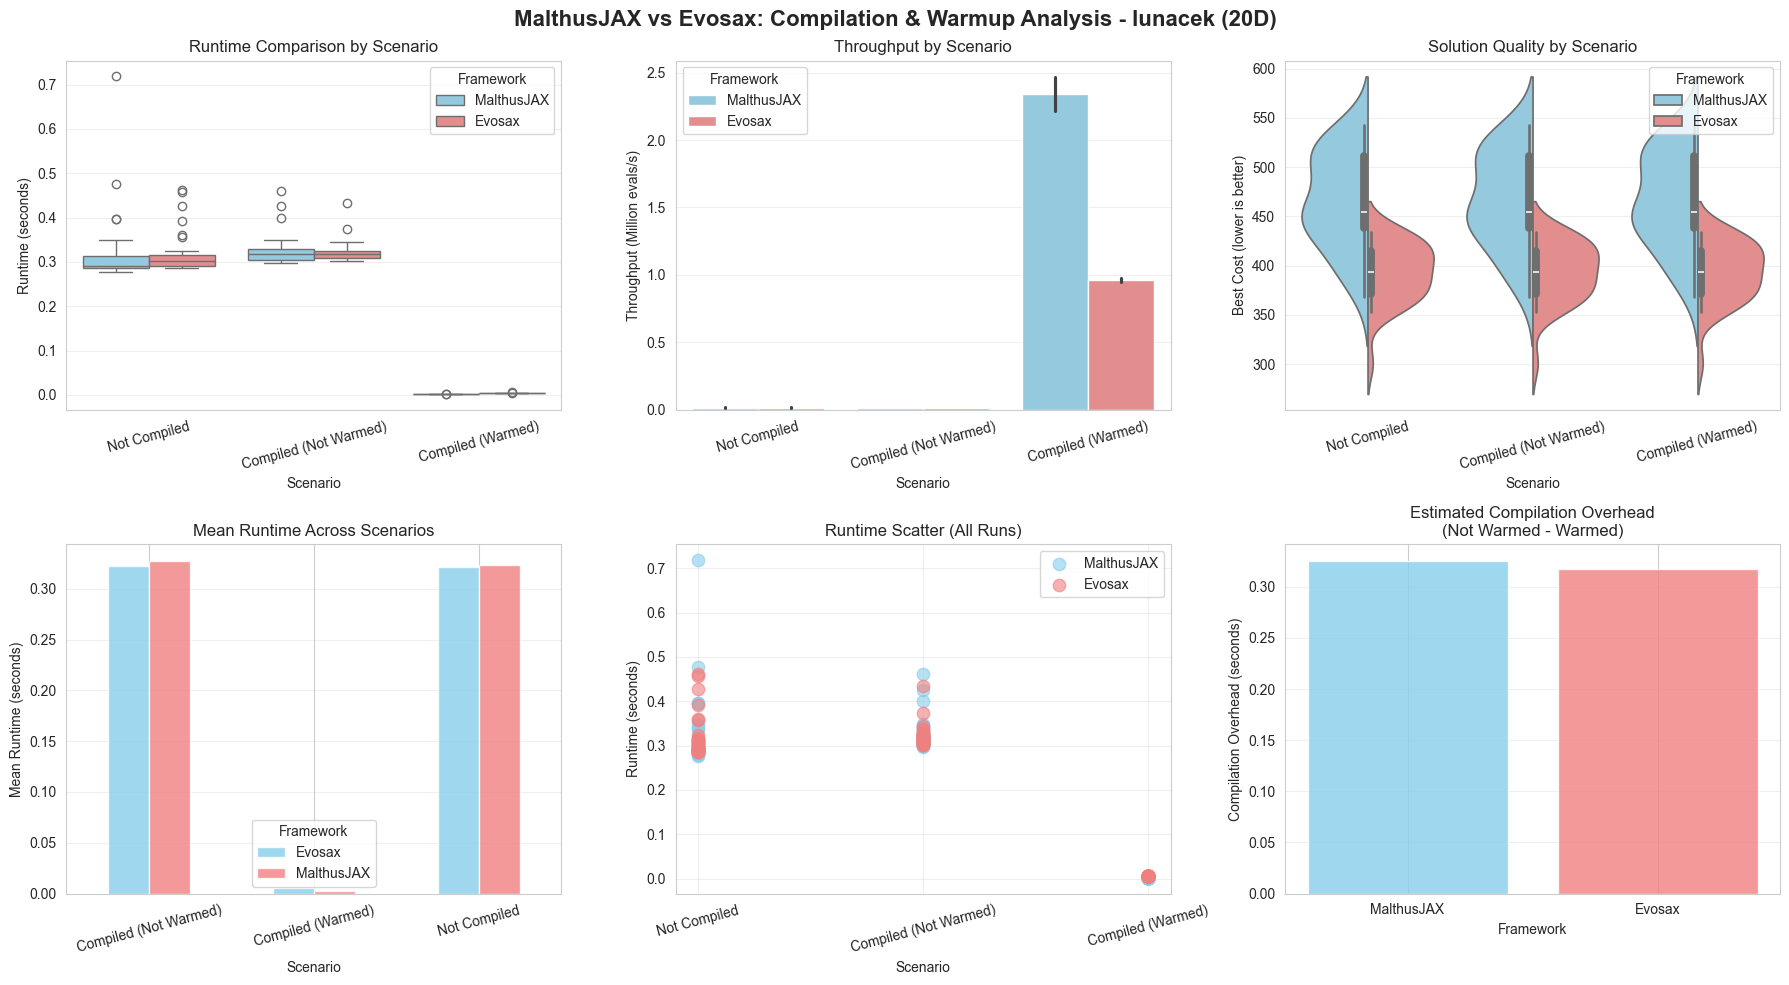

In [13]:
# Create comprehensive comparison plots
fig_comparison = plot_scenario_comparison(df_all_results)

## Raw Data & Export

In [14]:
# View all results
print("\n📊 All Experimental Results:")
display(df_all_results)

# Save to CSV
csv_filename = f"benchmark_results_{PROBLEM_NAME}_{DIMENSIONS}D.csv"
df_all_results.to_csv(csv_filename, index=False)
print(f"\n💾 Results saved to '{csv_filename}'")


📊 All Experimental Results:


,seed,best_cost,runtime,throughput,framework,compile,warmup,scenario,scenario_label
0,42,532.524536,0.291740,17138.537503,MalthusJAX,False,False,not_compiled,Not Compiled
1,43,505.671417,0.342524,14597.515052,MalthusJAX,False,False,not_compiled,Not Compiled
2,44,450.134094,0.294695,16966.686380,MalthusJAX,False,False,not_compiled,Not Compiled
3,45,483.503082,0.311224,16065.612199,MalthusJAX,False,False,not_compiled,Not Compiled
4,46,445.391785,0.396672,12604.872208,MalthusJAX,False,False,not_compiled,Not Compiled
...,...,...,...,...,...,...,...,...,...
175,67,365.771393,0.005178,965628.510913,Evosax,True,True,compiled_warmed,Compiled (Warmed)
176,68,428.957397,0.005323,939331.720864,Evosax,True,True,compiled_warmed,Compiled (Warmed)
177,69,353.537903,0.005124,975828.021032,Evosax,True,True,compiled_warmed,Compiled (Warmed)
178,70,426.988129,0.005587,894956.685017,Evosax,True,True,compiled_warmed,Compiled (Warmed)



💾 Results saved to 'benchmark_results_lunacek_20D.csv'


## Summary Report

In [15]:
# Generate final summary
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(f"\n📈 Problem: {PROBLEM_NAME.upper()} ({DIMENSIONS}D)")
print(f"   Population: {POPULATION_SIZE:,} | Generations: {NUM_GENERATIONS} | Runs: {NUM_RUNS}")

for scenario_label in df_all_results['scenario_label'].unique():
    print(f"\n📊 {scenario_label}:")
    df_scenario = df_all_results[df_all_results['scenario_label'] == scenario_label]
    
    for framework in ['MalthusJAX', 'Evosax']:
        df_fw = df_scenario[df_scenario['framework'] == framework]
        mean_cost = df_fw['best_cost'].mean()
        mean_time = df_fw['runtime'].mean()
        mean_throughput = df_fw['throughput'].mean() / 1e6
        
        print(f"   {framework}:")
        print(f"      Cost:       {mean_cost:.6f}")
        print(f"      Runtime:    {mean_time:.4f}s")
        print(f"      Throughput: {mean_throughput:.2f} M evals/s")

print(f"\n📊 Files Generated:")
print(f"   ✓ {csv_filename}")
if SAVE_IR:
    print(f"   ✓ malthusjax_ir.txt")
    print(f"   ✓ evosax_ir.txt")

print("\n" + "=" * 80)
print("✅ Benchmark Complete!")
print("=" * 80)

FINAL SUMMARY

📈 Problem: LUNACEK (20D)
   Population: 100 | Generations: 50 | Runs: 30

📊 Not Compiled:
   MalthusJAX:
      Cost:       465.915087
      Runtime:    0.3232s
      Throughput: 0.02 M evals/s
   Evosax:
      Cost:       392.799854
      Runtime:    0.3212s
      Throughput: 0.02 M evals/s

📊 Compiled (Not Warmed):
   MalthusJAX:
      Cost:       465.915087
      Runtime:    0.3276s
      Throughput: 0.02 M evals/s
   Evosax:
      Cost:       392.799854
      Runtime:    0.3228s
      Throughput: 0.02 M evals/s

📊 Compiled (Warmed):
   MalthusJAX:
      Cost:       465.915087
      Runtime:    0.0021s
      Throughput: 2.34 M evals/s
   Evosax:
      Cost:       392.799854
      Runtime:    0.0052s
      Throughput: 0.96 M evals/s

📊 Files Generated:
   ✓ benchmark_results_lunacek_20D.csv
   ✓ malthusjax_ir.txt
   ✓ evosax_ir.txt

✅ Benchmark Complete!
